In [1]:
import micropip
await micropip.install("openpyxl")
import pandas as pd

CORRECTED_FILE = "corrected future temp.xlsx"

SHEETS = [
    "sorted mid 2-4.5",
    "sorted long 2-4.5",
    "sorted mid 5-8.5",
    "sorted long 5-8.5",
]

MONTHLY_NAMES = [
    "Monthly_mid_2-4.5",
    "Monthly_long_2-4.5",
    "Monthly_mid_5-8.5",
    "Monthly_long_5-8.5",
]

# ── 1. LOAD ALL 4 SHEETS ─────────────────────────────────────────────────────
print("Loading sheets...")
data = {}
for sheet in SHEETS:
    df = pd.read_excel(CORRECTED_FILE, sheet_name=sheet)
    df = df.rename(columns={df.columns[0]: "date"})
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"])
    data[sheet] = df
    print(f"  {sheet}: {len(df)} rows, {len(df.columns)-1} model columns")

# ── 2. ADD ENSEMBLE MEAN COLUMN TO EACH SHEET ────────────────────────────────
print("\nCalculating ensemble means...")
for sheet in SHEETS:
    df = data[sheet]
    model_cols = [c for c in df.columns if c != "date"]
    df["Ensemble_Mean"] = df[model_cols].mean(axis=1)
    data[sheet] = df
    print(f"  Done: {sheet}")

# ── 3. WRITE EVERYTHING TO EXCEL ─────────────────────────────────────────────
print("\nWriting to Excel...")
with pd.ExcelWriter(CORRECTED_FILE, engine="openpyxl",
                    mode="a", if_sheet_exists="replace") as writer:

    # Sheets 1–4: original data + ensemble mean column added
    for sheet in SHEETS:
        data[sheet].to_excel(writer, sheet_name=sheet, index=False)
        print(f"  Updated: {sheet}")

    # Sheet 5: monthly means of ensemble mean for all 4 scenario/period combos
    ens_monthly = pd.DataFrame({"Month": range(1, 13)})
    for sheet in SHEETS:
        df = data[sheet].copy()
        df["month"] = df["date"].dt.month
        monthly_ens = df.groupby("month")["Ensemble_Mean"].mean()
        ens_monthly[sheet] = monthly_ens.values
    ens_monthly.to_excel(writer, sheet_name="Ensemble_Monthly_Means", index=False)
    print("  Created: Ensemble_Monthly_Means")

    # Sheets 6–9: monthly means of each individual model
    for sheet, monthly_name in zip(SHEETS, MONTHLY_NAMES):
        df = data[sheet].copy()
        df["month"] = df["date"].dt.month
        model_cols = [c for c in df.columns
                      if c not in ["date", "month", "Ensemble_Mean"]]
        monthly = df.groupby("month")[model_cols].mean().reset_index()
        monthly = monthly.rename(columns={"month": "Month"})
        monthly.to_excel(writer, sheet_name=monthly_name, index=False)
        print(f"  Created: {monthly_name}")

print("\nAll done! Your file now has 9 sheets.")

Loading sheets...
  sorted mid 2-4.5: 4017 rows, 33 model columns
  sorted long 2-4.5: 4017 rows, 33 model columns
  sorted mid 5-8.5: 4017 rows, 34 model columns
  sorted long 5-8.5: 4017 rows, 34 model columns

Calculating ensemble means...
  Done: sorted mid 2-4.5
  Done: sorted long 2-4.5
  Done: sorted mid 5-8.5
  Done: sorted long 5-8.5

Writing to Excel...
  Updated: sorted mid 2-4.5
  Updated: sorted long 2-4.5
  Updated: sorted mid 5-8.5
  Updated: sorted long 5-8.5
  Created: Ensemble_Monthly_Means
  Created: Monthly_mid_2-4.5
  Created: Monthly_long_2-4.5
  Created: Monthly_mid_5-8.5
  Created: Monthly_long_5-8.5

All done! Your file now has 9 sheets.


SSP2-4.5: 33 models
SSP5-8.5: 34 models


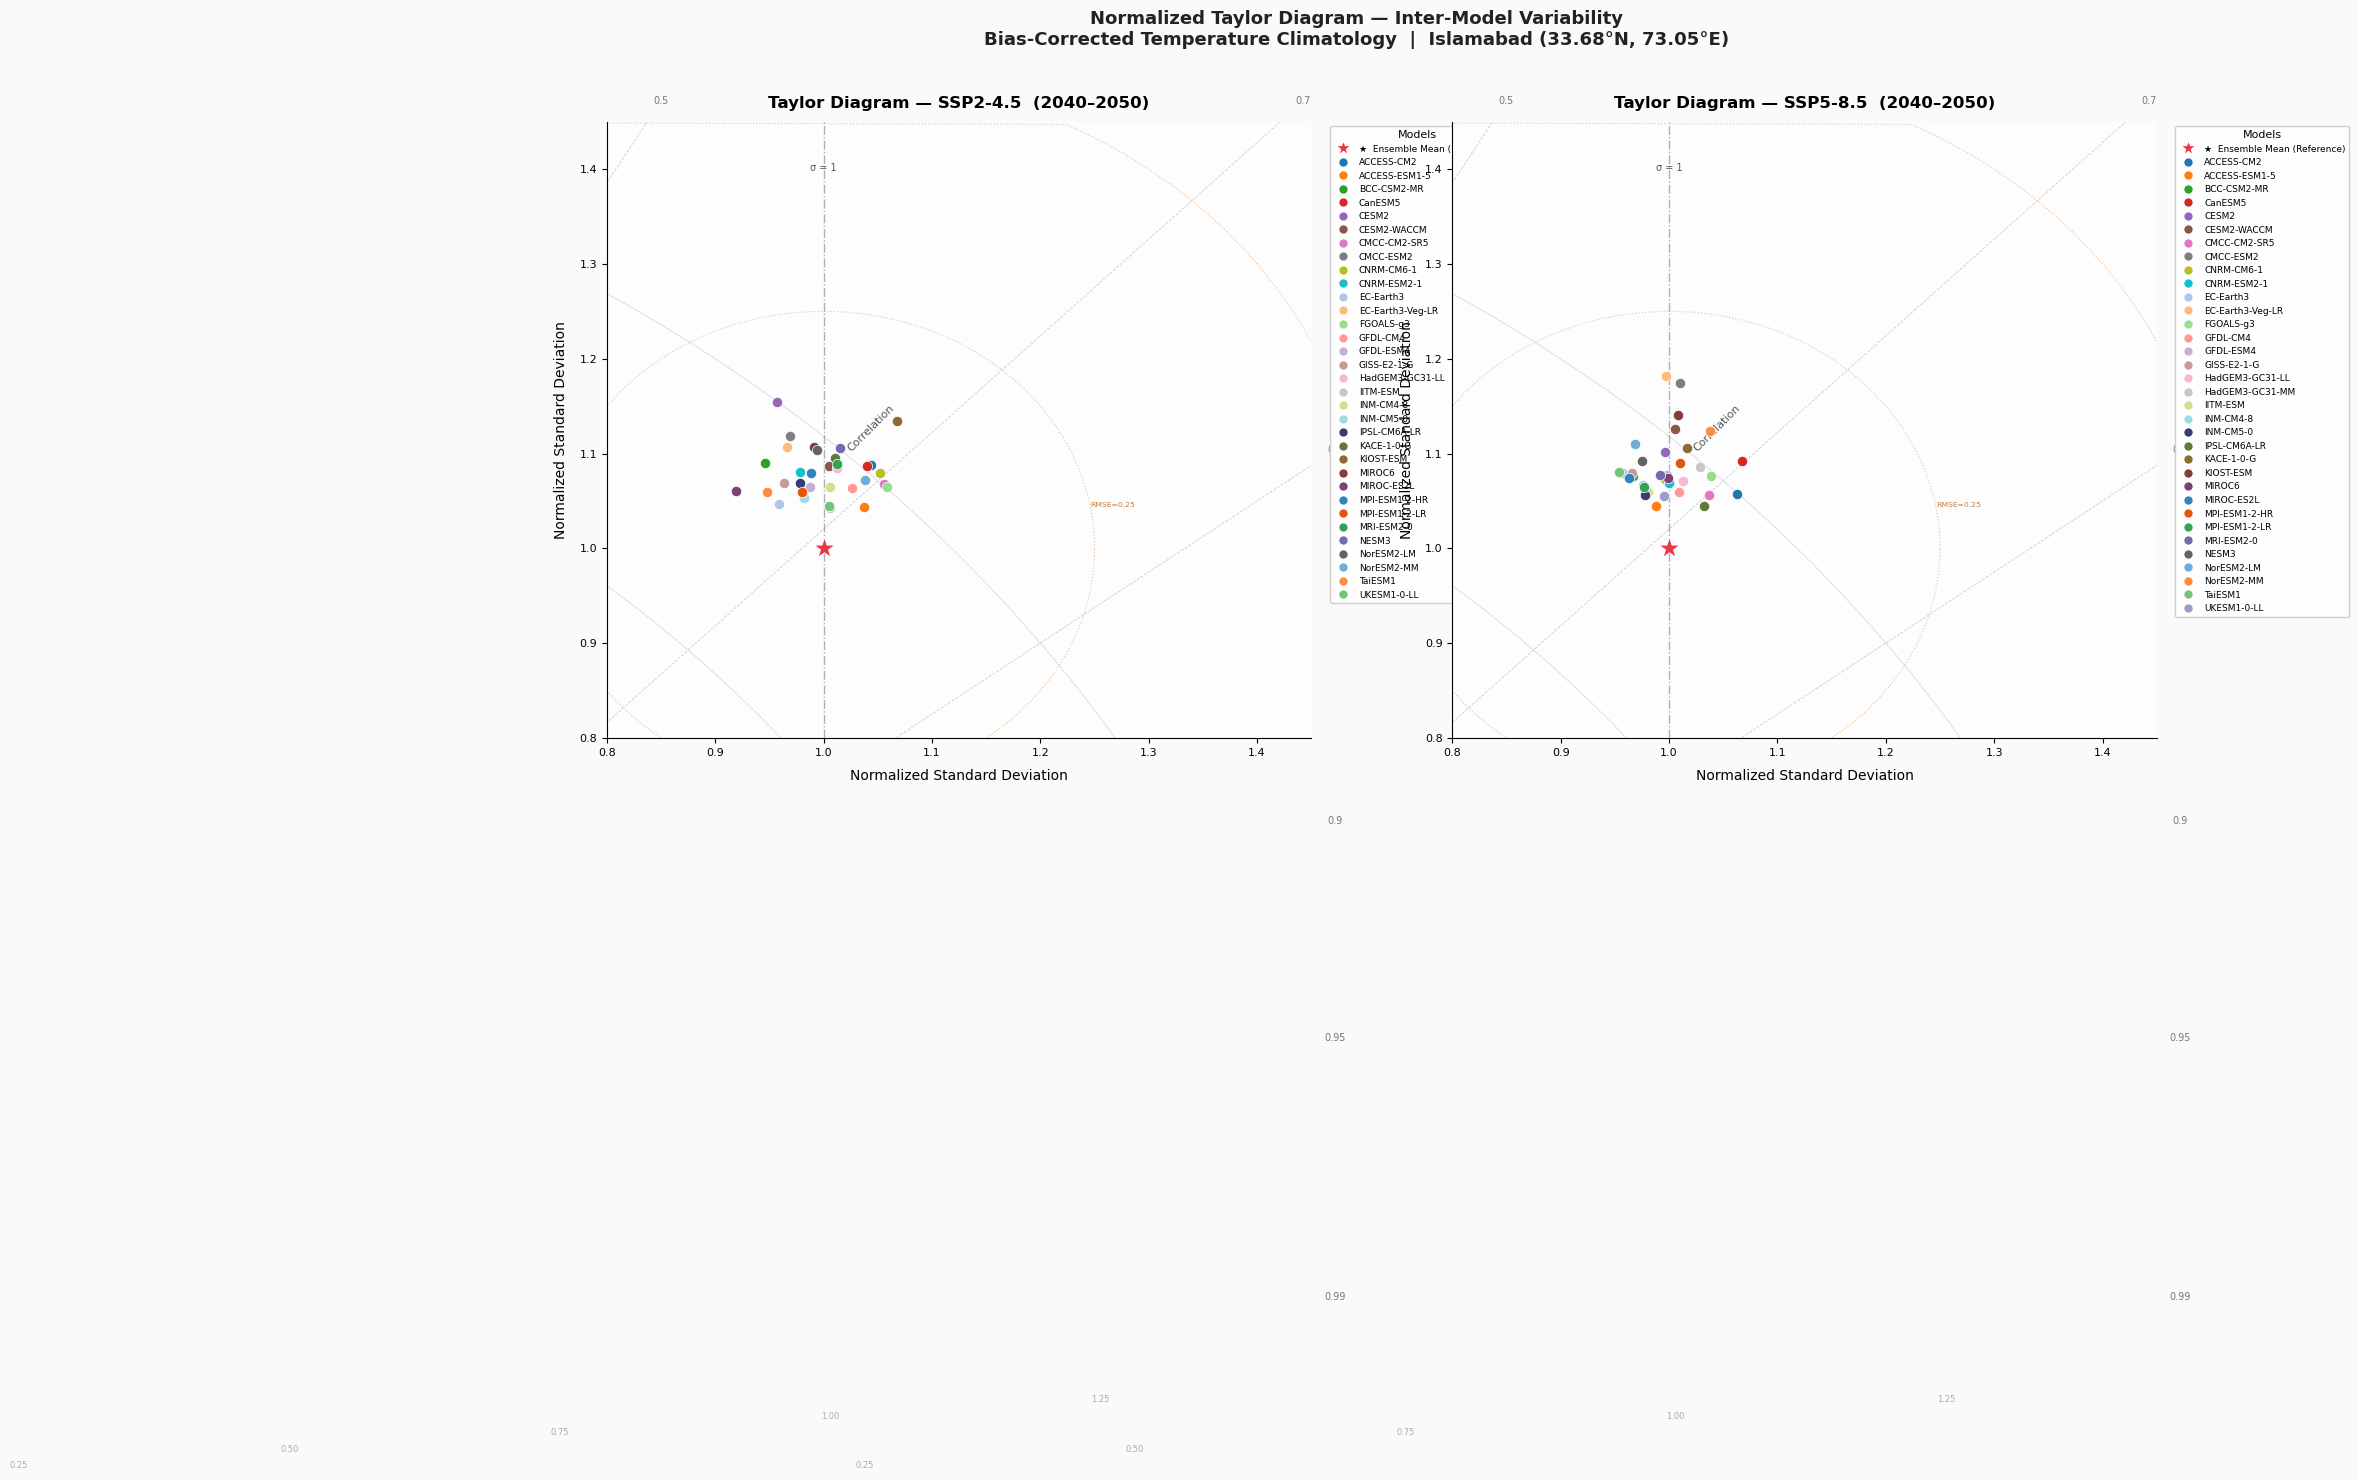

Saved: taylor_diagram_normalized_2040_2050.png


In [9]:
import micropip
await micropip.install("openpyxl")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CORRECTED_FILE = "corrected future temp.xlsx"

# ── 1. LOAD REFERENCE (ensemble monthly means) ───────────────────────────────
ens_monthly = pd.read_excel(CORRECTED_FILE, sheet_name="Ensemble_Monthly_Means")
ens_monthly = ens_monthly.set_index("Month")

ref_245 = ens_monthly["sorted mid 2-4.5"].values   # 12 monthly means
ref_585 = ens_monthly["sorted mid 5-8.5"].values   # 12 monthly means

# ── 2. LOAD MODEL MONTHLY MEANS (mid-century only) ───────────────────────────
monthly_245 = pd.read_excel(CORRECTED_FILE, sheet_name="Monthly_mid_2-4.5")
monthly_245 = monthly_245.set_index("Month")

monthly_585 = pd.read_excel(CORRECTED_FILE, sheet_name="Monthly_mid_5-8.5")
monthly_585 = monthly_585.set_index("Month")

print(f"SSP2-4.5: {monthly_245.shape[1]} models")
print(f"SSP5-8.5: {monthly_585.shape[1]} models")


# ── 3. NORMALIZED TAYLOR STATS ───────────────────────────────────────────────
def taylor_stats(ref, model):
    ref   = np.array(ref,   dtype=float)
    model = np.array(model, dtype=float)
    corr      = np.corrcoef(ref, model)[0, 1]
    ref_std   = np.std(ref,   ddof=1)
    model_std = np.std(model, ddof=1)
    norm_std  = model_std / ref_std
    # Normalized centred RMSE from Taylor identity
    norm_rmse = np.sqrt(1 + norm_std**2 - 2 * norm_std * corr)
    return corr, norm_std, norm_rmse


# ── 4. PLOT FUNCTION ──────────────────────────────────────────────────────────
def plot_taylor(monthly_df, ref_series, title, ax, colors):
    MAX = 1.45   # axis limit in normalized std units

    theta = np.linspace(0, np.pi / 2, 500)

    # ── Normalized std arcs ──────────────────────────────────────────────────
    for r in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5]:
        arc_x = r * np.cos(theta)
        arc_y = r * np.sin(theta)
        mask = (arc_x <= MAX) & (arc_y <= MAX)
        ax.plot(arc_x[mask], arc_y[mask],
                color="#dedede", linewidth=0.7, zorder=1)
        # Label at low angle so it stays inside
        lx = r * np.cos(np.radians(4))
        ly = r * np.sin(np.radians(4))
        if lx <= MAX and ly <= MAX:
            ax.text(lx, ly + 0.01, f"{r:.2f}",
                    fontsize=6, color="#aaaaaa", ha="left", va="bottom")

    # ── Correlation lines ────────────────────────────────────────────────────
    for c in [0.5, 0.7, 0.8, 0.9, 0.95, 0.99]:
        angle = np.arccos(c)
        tan_a = np.tan(angle) if angle > 1e-6 else 1e-9
        # Find where line exits the plot box
        x_at_ymax = MAX / tan_a
        y_at_xmax = MAX * tan_a
        if y_at_xmax <= MAX:
            ex, ey = MAX, y_at_xmax
        else:
            ex, ey = x_at_ymax, MAX
        ax.plot([0, ex], [0, ey],
                color="#cccccc", linewidth=0.6, linestyle="--", zorder=1)
        ax.text(ex * 1.015, ey * 1.015, f"{c}",
                fontsize=7, color="#777777", ha="center", va="center")

    # Correlation axis label
    ax.text(MAX * 0.72, MAX * 0.76, "Correlation",
            fontsize=8, color="#555555", rotation=45, ha="center")

    # ── Normalized RMS contours (centred on reference at x=1, y=0) ──────────
    for rms_val in [0.25, 0.5, 0.75, 1.0]:
        rms_theta = np.linspace(0, 2 * np.pi, 500)
        cx = 1.0 + rms_val * np.cos(rms_theta)
        cy = 1.0 + rms_val * np.sin(rms_theta)
        mask = (cx >= 0) & (cx <= MAX) & (cy >= 0) & (cy <= MAX)
        if mask.any():
            ax.plot(cx[mask], cy[mask],
                    color="#f0c4a0", linewidth=0.85,
                    linestyle=":", zorder=1)
        # Label only if inside plot
        lx = 1.0 + rms_val * np.cos(np.radians(10))
        ly = 1.0 + rms_val * np.sin(np.radians(10))
        if 0 <= lx <= MAX and 0 <= ly <= MAX:
            ax.text(lx, ly, f"RMSE={rms_val:.2f}",
                    fontsize=5.5, color="#c07030", alpha=0.9, zorder=2)

    # ── Reference std line at norm_std = 1 ───────────────────────────────────
    ax.axvline(x=1.0, color="#555555", linewidth=1.0,
               linestyle="-.", alpha=0.45, zorder=2)
    ax.text(1.0, MAX * 0.97, "σ = 1",
            fontsize=7, ha="center", va="top", color="#555555")

    # ── Model dots ───────────────────────────────────────────────────────────
    models = monthly_df.columns.tolist()
    legend_handles = []

    for i, model in enumerate(models):
        model_vals = monthly_df[model].values
        corr, norm_std, _ = taylor_stats(ref_series, model_vals)
        if np.isnan(corr) or np.isnan(norm_std):
            continue
        angle = np.arccos(np.clip(corr, -1, 1))
        x = norm_std * np.cos(angle)
        y = norm_std * np.sin(angle) + 1.0
        color = colors[i % len(colors)]
        ax.scatter(x, y, color=color, s=55, zorder=5,
                   edgecolors="white", linewidths=0.5)
        legend_handles.append((model, color))

    # ── Reference star ───────────────────────────────────────────────────────
    # At (1, 0) in Taylor space — offset y slightly so star isn't clipped
    ax.scatter(1.0, 1.0, marker="*", s=250, color="#e63946",
           zorder=7, edgecolors="white", linewidths=0.6)

    # ── Axis formatting ──────────────────────────────────────────────────────
    ax.set_xlim(0.8, MAX)
    ax.set_ylim(0.8, MAX)
    ax.set_xlabel("Normalized Standard Deviation", fontsize=10, labelpad=8)
    ax.set_ylabel("Normalized Standard Deviation", fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.1))

    return legend_handles


# ── 5. COLOURS ────────────────────────────────────────────────────────────────
base_colors = [
    "#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
    "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf",
    "#aec7e8","#ffbb78","#98df8a","#ff9896","#c5b0d5",
    "#c49c94","#f7b6d2","#c7c7c7","#dbdb8d","#9edae5",
    "#393b79","#637939","#8c6d31","#843c39","#7b4173",
    "#3182bd","#e6550d","#31a354","#756bb1","#636363",
    "#6baed6","#fd8d3c","#74c476","#9e9ac8"
]


# ── 6. DRAW ───────────────────────────────────────────────────────────────────
plt.close("all")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.patch.set_facecolor("#fafafa")

for ax, monthly_df, ref_series, ssp_label in [
    (axes[0], monthly_245, ref_245, "SSP2-4.5  (2040–2050)"),
    (axes[1], monthly_585, ref_585, "SSP5-8.5  (2040–2050)"),
]:
    ax.set_facecolor("#fdfdfd")
    handles = plot_taylor(monthly_df, ref_series,
                          f"Taylor Diagram — {ssp_label}",
                          ax, base_colors)

    # Legend
    legend_elements = [
        plt.Line2D([0], [0], marker="*", color="w",
                   markerfacecolor="#e63946", markersize=12,
                   label="★  Ensemble Mean (Reference)")
    ] + [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=c, markersize=7, label=name)
        for name, c in handles
    ]

    ax.legend(handles=legend_elements,
              loc="upper left",
              bbox_to_anchor=(1.02, 1),
              fontsize=6.5,
              frameon=True,
              framealpha=0.95,
              edgecolor="#cccccc",
              title="Models",
              title_fontsize=8)

fig.suptitle(
    "Normalized Taylor Diagram — Inter-Model Variability\n"
    "Bias-Corrected Temperature Climatology  |  Islamabad (33.68°N, 73.05°E)",
    fontsize=13, fontweight="bold", y=1.02, color="#222222"
)

plt.tight_layout
plt.savefig("taylor_diagram_normalized_2040_2050.png", dpi=180,
            bbox_inches="tight", facecolor="#fafafa")
plt.show()
print("Saved: taylor_diagram_normalized_2040_2050.png")